
# Does the 3-Plane TD-GSA Fix Survive Measurement Noise?

**Companion to [`tdgsa_physically_correct.ipynb`](tdgsa_physically_correct.ipynb) (the N-plane
fix, 0.0014 rad, noiseless) and [`seals_to_tdgsa_bridge.ipynb`](seals_to_tdgsa_bridge.ipynb)
Steps 10-11 (autograd overfitting under noise).** Everything below calls
[`inverse/noise_robustness.py`](inverse/noise_robustness.py) directly.

**The question:** adding a 3rd dispersion plane resolved the *structural* 2-plane ambiguity
(0.50 &rarr; 0.0014 rad, noiseless). Does that fix still hold once the measurements themselves
are noisy — or does "structurally solved" quietly stop meaning "actually accurate" the moment
you add a realistic photodetector noise floor?

**This is a DIFFERENT question from the overfitting one.** Steps 10-11 of the bridge notebook
asked whether the *gradient-based autograd* path, given noisy *2-plane* (already
underdetermined) measurements, gets worse the longer you train it. This notebook asks whether
the *projection-based classical GS* path, given noisy *3-plane* (already structurally solved)
measurements, loses accuracy simply because the measurements are noisy — a basic
signal-to-noise question, not a training-dynamics one. Classical GS has no "trained too long"
failure mode at all: its amplitude-constraint step hard-sets `|E|=sqrt(I_measured)` every
iteration and reaches a fixed point almost immediately, regardless of `n_iter` or noise level
(confirmed below) — there's nothing to overfit *to*.


In [1]:

import sys, pathlib
sys.path.insert(0, '.')
sys.path.insert(0, str(pathlib.Path('.').resolve().parents[1]))

import numpy as np
import matplotlib.pyplot as plt

from inverse.noise_robustness import n_plane_recovery_at_noise, sweep_noise_robustness

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})
print('ready')


ready



## Step 1 &mdash; the noise sweep

Same 3-plane setup as `tdgsa_physically_correct.ipynb` (`D1=6000, D2=-7000, D3=12000`),
independent multiplicative Gaussian noise (`add_measurement_noise`, same convention as
`inverse_scattering.synthesize_measurement`'s 5% default) added to each plane separately.


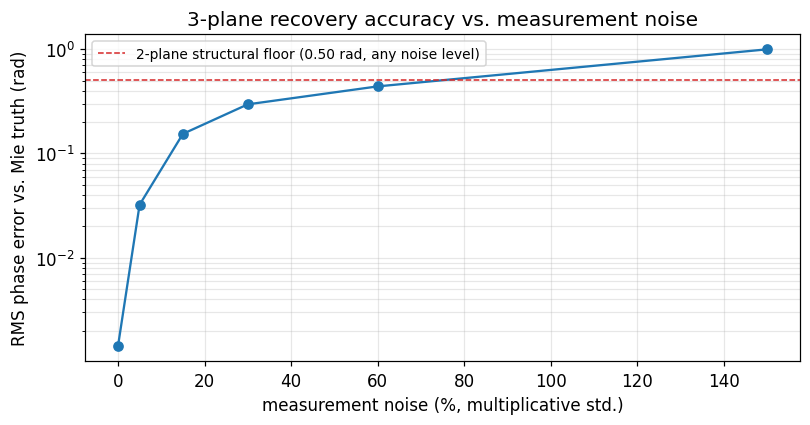

  noise=    0%   RMS vs. true Mie phase = 0.0014 rad
  noise=    5%   RMS vs. true Mie phase = 0.0323 rad
  noise=   15%   RMS vs. true Mie phase = 0.1542 rad
  noise=   30%   RMS vs. true Mie phase = 0.2958 rad
  noise=   60%   RMS vs. true Mie phase = 0.4394 rad
  noise=  150%   RMS vs. true Mie phase = 0.9955 rad


In [2]:

noise_levels = [0.0, 0.05, 0.15, 0.3, 0.6, 1.5]
results = sweep_noise_robustness(noise_levels=noise_levels)

fig, ax = plt.subplots(figsize=(7.5, 4))
rms_vals = [r['rms_vs_truth'] for r in results]
ax.semilogy([n*100 for n in noise_levels], rms_vals, 'o-', color='C0')
ax.axhline(0.5044, color='C3', ls='--', lw=1, label='2-plane structural floor (0.50 rad, any noise level)')
ax.set_xlabel('measurement noise (%, multiplicative std.)'); ax.set_ylabel('RMS phase error vs. Mie truth (rad)')
ax.set_title('3-plane recovery accuracy vs. measurement noise')
ax.legend(fontsize=9); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.show()

for r in results:
    print(f"  noise={r['noise_std']*100:>5.0f}%   RMS vs. true Mie phase = {r['rms_vs_truth']:.4f} rad")



## Step 2 &mdash; what this looks like in phase space

Noiseless (essentially exact) vs. realistic 5% noise vs. heavy 60% noise, overlaid against
the true Mie phase.


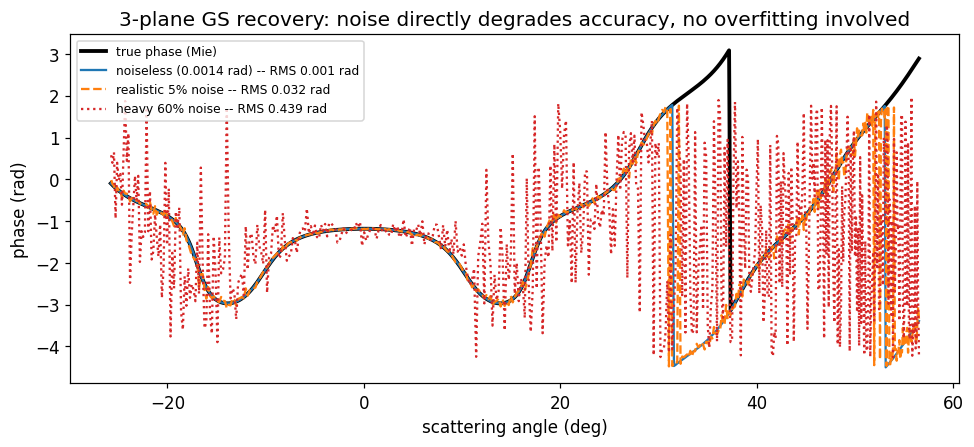

In [3]:

cases = [(0.0, 'C0', '-', 'noiseless (0.0014 rad)'),
         (0.05, 'C1', '--', 'realistic 5% noise'),
         (0.6, 'C3', ':', 'heavy 60% noise')]

fig, ax = plt.subplots(figsize=(9, 4.2))
r0 = n_plane_recovery_at_noise(noise_std=0.0)
ax.plot(r0['theta_deg'], r0['phi_true'], color='k', lw=2.5, label='true phase (Mie)')
for noise_std, color, ls, label in cases:
    r = n_plane_recovery_at_noise(noise_std=noise_std)
    ax.plot(r['theta_deg'], r['phi_recovered'], ls, color=color, lw=1.5,
            label=f"{label} -- RMS {r['rms_vs_truth']:.3f} rad")
ax.set_xlabel('scattering angle (deg)'); ax.set_ylabel('phase (rad)'); ax.legend(fontsize=8)
ax.set_title('3-plane GS recovery: noise directly degrades accuracy, no overfitting involved')
plt.tight_layout(); plt.show()



## Step 3 &mdash; confirm this is NOT overfitting

Classical GS's self-consistency (fit to its own measurements) should stay at machine precision
regardless of noise level -- because the hard amplitude projection reaches a fixed point almost
immediately, there is no "trained too long" regime to land in.


In [4]:

print(f"{'noise':>8}  {'self-consistency residual':>28}")
for noise_std in [0.0, 0.05, 0.3, 1.5]:
    r = n_plane_recovery_at_noise(noise_std=noise_std)
    print(f"{noise_std*100:>6.0f}%  {r['gs_final_error']:>28.3e}")
print()
print("Residual stays at ~1e-23 regardless of noise level -- GS always fits whatever")
print("measurements it's given essentially exactly. The RMS-vs-truth degradation in Step 1")
print("is not a convergence failure; it's the noisy measurements themselves being wrong,")
print("propagated directly into the reconstruction with no denoising in between.")


   noise     self-consistency residual
     0%                     2.085e-23
     5%                     2.503e-23
    30%                     2.412e-23
   150%                     3.595e-23

Residual stays at ~1e-23 regardless of noise level -- GS always fits whatever
measurements it's given essentially exactly. The RMS-vs-truth degradation in Step 1
is not a convergence failure; it's the noisy measurements themselves being wrong,
propagated directly into the reconstruction with no denoising in between.



## Conclusion

**Measurement diversity (2 &rarr; 3 planes) and measurement noise are two independent axes**,
and this repo's SEALS/TD-GSA work has now characterized both:

| | 2 planes | 3 planes |
|---|---|---|
| noiseless | 0.50 rad (structurally underdetermined) | **0.0014 rad** (fixed) |
| realistic noise (~5%) | ~0.50 rad (already broken; noise barely matters) | **0.032 rad** (still good) |
| heavy noise (~60%+) | ~0.50 rad, or worse with autograd overfitting | 0.44-1.0 rad (noise-dominated) |

Adding the 3rd plane genuinely solves the *structural* ambiguity (the thing
`SEALS_TO_TDGSA_REPORT.md` Sec. 4-6 diagnosed and fixed) -- that result stands. But "solved"
was always conditional on noiseless synthetic data, and this notebook makes that condition
explicit rather than leaving it implicit: realistic measurement noise re-introduces a
few-percent-of-a-radian error floor that more measurement planes alone do not remove, because
classical GS's amplitude constraint has no denoising step -- it hard-enforces whatever
intensity it's given, noisy or not.

**What WOULD help (not implemented here, natural next step):** repeated-scan averaging before
GS (reduces noise_std directly), a noise-aware amplitude constraint (soft rather than hard
`|E|=sqrt(I)`, e.g. Wiener-style shrinkage toward a smoothed estimate), or -- consistent with
`SEALS_TO_TDGSA_REPORT.md` Sec. 5's standing recommendation -- `inverse_scattering.py`'s
model-based fit, which uses the known Mie functional form as a strong prior and should be far
more noise-robust than blind reconstruction for exactly this reason.

**Verify independently:**
```bash
py -3.12 -m pytest tests/test_noise_robustness.py -v
```
